In [ ]:
!pip install -q -U transformers datasets peft accelerate sentencepiece
!pip install -q sacrebleu
!pip uninstall -y torchao -q

import torch, transformers, peft
print("torch       :", torch.__version__)
print("transformers:", transformers.__version__)
print("peft        :", peft.__version__)
print("GPU         :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "❌ KHÔNG CÓ GPU")

# ⚠️ requirements.txt của backend PHẢI pin đúng version transformers này.
# Tokenizer M2M-100 đổi hành vi giữa v4 và v5 (special_tokens_map.json biến mất).
# Train một version mà serve version khác = lỗi âm thầm rất khó truy.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 111.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 7.2 MB/s eta 0:00:00
torch       : 2.11.0+cu128
transformers: 5.15.0
peft        : 0.20.0
GPU         : Tesla T4


In [ ]:
import json, random, re, unicodedata
from datasets import Dataset

random.seed(42)
JP_RE = re.compile(r"[\u3040-\u309f\u30a0-\u30ff\u4e00-\u9fff]")
RAW_COUNTS = {}

def read_jsonl(path):
    rows = []
    try:
        for line in open(path, encoding="utf-8"):
            line = line.strip()
            if line:
                d = json.loads(line)
                if d.get("vi") and d.get("ja"):
                    rows.append((d["vi"].strip(), d["ja"].strip()))
    except FileNotFoundError:
        print(f"❌ không tìm thấy {path}")
        raise
    RAW_COUNTS[path] = len(rows)
    return rows

# ---------------------------------------------------------------- nhiễu JA
# 🔴 SỬA v5: ー (U+30FC) và ・ (U+30FB) là MỘT PHẦN CỦA TỪ, không phải dấu câu.
# Bản v4 xoá chúng -> サーバー→サバ, ページネーション→ペジネション, レビュー→レビュ
# Parakeet-JA (NeMo CTC) KHÔNG bao giờ sinh ra như vậy: ー nằm trong vocab như
# token bình thường. Bug này làm hỏng ~25% dòng train tiếng Nhật.
JA_PUNCT = re.compile(r"[。、！？!?,.「」『』（）()…―〜]")

def noise_ja(s, rng=None, level=1.0):
    """Parakeet-JA greedy CTC: không dấu câu, không khoảng trắng."""
    s = JA_PUNCT.sub("", s)
    return re.sub(r"[\s\u3000]+", "", s)

# ---------------------------------------------------------------- nhiễu VI
# 🔴 SỬA v5: bản v4 chỉ mô phỏng ĐỊNH DẠNG (bỏ dấu câu + lowercase), không mô
# phỏng LỖI. Zipformer-VI trong phòng ồn còn sai dấu thanh, nhầm phụ âm, nuốt từ.
# Đó là lý do lab chỉ mất 7.9% chrF khi sang nhiễu còn app thật tệ hơn nhiều.
TONES   = "\u0300\u0301\u0303\u0309\u0323"          # huyền sắc ngã hỏi nặng
ASCII_W = re.compile(r"^[a-z0-9._/#-]+$")            # dev, push, api -> không bẻ chính tả
VN_CONFUS = [("d","gi"),("gi","d"),("ch","tr"),("tr","ch"),
             ("s","x"),("x","s"),("n","l"),("l","n")]

def _corrupt_tone(w, rng):
    d = list(unicodedata.normalize("NFD", w))
    idx = [i for i, c in enumerate(d) if c in TONES]
    if not idx:
        return w
    i = rng.choice(idx)
    d[i] = "" if rng.random() < 0.45 else rng.choice([t for t in TONES if t != d[i]])
    return unicodedata.normalize("NFC", "".join(d))

def noise_vi(s, rng=None, level=1.0):
    """level 0 = chỉ định dạng | 0.5 = phòng yên | 1.0 = phòng ồn (WER ~26%)"""
    s = unicodedata.normalize("NFC", s)
    s = re.sub(r"[.,!?;:\"'’“”()\[\]\-–—…]", " ", s)
    s = re.sub(r"\s+", " ", s).strip().lower()
    if not level or rng is None:
        return s
    words, out = s.split(), []
    for w in words:
        if ASCII_W.match(w):                         # thuật ngữ kỹ thuật: giữ nguyên
            out.append(w); continue
        r = rng.random()
        if r < 0.04 * level and len(words) > 6:
            continue                                 # nuốt từ
        elif r < 0.24 * level:
            w = _corrupt_tone(w, rng)
        elif r < 0.30 * level:
            for a, b in VN_CONFUS:
                if w.startswith(a):
                    w = b + w[len(a):]; break
        out.append(w)
    return " ".join(out)

# ---------------------------------------------------------------- nạp data
# 🔴 SỬA v5: BỎ HẲN vnjp_it.jsonl.
# Nó không phải data IT — là kết quả grep từ khoá trên corpus tổng hợp
# (Wikipedia + phụ đề phim + TED). 20% lệch cặp, chỉ 15% thể lịch sự.
# Nó chiếm 52% data IT của v4 và là nguồn của các lỗi 占領 / 抱擁 / register lộn xộn.
trusted_pairs = read_jsonl("it_dataset_clean.jsonl")
gen_pairs_all = read_jsonl("general_clean.jsonl")

seen = set()
trusted_pairs = [(v, j) for v, j in trusted_pairs if not (v in seen or seen.add(v))]

# 🔴 SỬA v5: v4 KHÔNG dedup general với trusted -> eval có thể rò rỉ vào train.
gen_pairs_all = [(v, j) for v, j in gen_pairs_all if v not in seen]

# ---- eval cố định (seed 42) ----
random.shuffle(trusted_pairs)
n_eval = int(len(trusted_pairs) * 0.15)
eval_pairs, train_trusted = trusted_pairs[:n_eval], trusted_pairs[n_eval:]

# ---- v6: cộng thêm data mới, KHÔNG đụng eval_pairs ----
# new_it_pairs_v6.jsonl = 20 câu lọc thủ công từ vnjp_review.jsonl (giữ đúng
# chủ đề IT + cặp khớp nghĩa) + 28 câu tự soạn nhắm 2 pattern chưa generalize
# ở v5 (kính ngữ でしょうか lồng, "giúp + động từ cụ thể"). Đã kiểm tra: không
# trùng eval_pairs, không trùng it_dataset_clean/general_clean hiện có.
extra_pairs = read_jsonl("new_it_pairs_v6.jsonl")
train_trusted = train_trusted + extra_pairs
print(f"v6: +{len(extra_pairs)} câu mới -> train_trusted = {len(train_trusted)} "
      f"(eval_pairs giữ nguyên {len(eval_pairs)} câu như v5, so sánh được)")

GEN_RATIO = 0.20                     # giữ nguyên như v4 để so sánh được
max_gen = int(len(train_trusted) * GEN_RATIO / (1 - GEN_RATIO))
gen_pairs = gen_pairs_all[:]
random.shuffle(gen_pairs)
gen_pairs = gen_pairs[:max_gen]
base_pairs = train_trusted + gen_pairs

print(f"IT train: {len(train_trusted)} | General: {len(gen_pairs)} | Eval: {len(eval_pairs)}")
print(f"⚠️  Eval {len(eval_pairs)} cặp/chiều -> khoảng tin cậy chrF khoảng ±3 điểm.")
print("    Chênh lệch nhỏ hơn thế KHÔNG đọc được. Xem CI ở CELL 9.")

def to_rows(pairs, rng=None, levels=(0.0,)):
    rows = []
    for vi, ja in pairs:
        lv_j = rng.choice(levels) if rng else levels[0]
        lv_v = rng.choice(levels) if rng else levels[0]
        rows.append({"src_text": noise_ja(ja, rng, lv_j), "tgt_text": vi,
                     "src_lang": "ja", "tgt_lang": "vi", "level": lv_j})
        rows.append({"src_text": noise_vi(vi, rng, lv_v), "tgt_text": ja,
                     "src_lang": "vi", "tgt_lang": "ja", "level": lv_v})
    return rows

rng = random.Random(0)
# Train thấy đủ dải: sạch, phòng yên, phòng ồn
train_dataset    = Dataset.from_list(to_rows(base_pairs, rng, levels=(0.0, 0.5, 1.0)))
eval_dataset_raw = Dataset.from_list(to_rows(eval_pairs, None, levels=(0.0,)))
eval_noisy_raw   = Dataset.from_list(to_rows(eval_pairs, random.Random(99), levels=(1.0,)))

print(f"\n📦 Train {len(train_dataset)} row | Eval sạch {len(eval_dataset_raw)} | Eval nhiễu {len(eval_noisy_raw)}")
print("\n--- Kiểm tra bug ー đã hết chưa (phải thấy đủ ー) ---")
for _, ja in eval_pairs[:1]:
    print(f"  gốc  : {ja}\n  nhiễu: {noise_ja(ja)}")
print("\n--- Nhiễu VI ---")
_r = random.Random(3)
for vi, _ in eval_pairs[:3]:
    print(f"  gốc  : {vi}\n  nhiễu: {noise_vi(vi, _r, 1.0)}")

v6: +67 câu mới -> train_trusted = 657 (eval_pairs giữ nguyên 103 câu như v5, so sánh được)
IT train: 657 | General: 164 | Eval: 103
⚠️  Eval 103 cặp/chiều -> khoảng tin cậy chrF khoảng ±3 điểm.
    Chênh lệch nhỏ hơn thế KHÔNG đọc được. Xem CI ở CELL 9.

📦 Train 1642 row | Eval sạch 206 | Eval nhiễu 206

--- Kiểm tra bug ー đã hết chưa (phải thấy đủ ー) ---
  gốc  : mainに直接プッシュせず、プルリクエストを作成してください。
  nhiễu: mainに直接プッシュせずプルリクエストを作成してください

--- Nhiễu VI ---
  gốc  : Đừng push trực tiếp lên main, tạo pull request đi.
  nhiễu: đưng push trực tiếp lên main pull request đi
  gốc  : Infra mình quản bằng Terraform cho dễ tái tạo.
  nhiễu: infra mình quạn bằng terraform cho dễ tại tạo
  gốc  : Chia nhỏ task ra để estimate cho chính xác hơn.
  nhiễu: chia nhỏ task ra đê estimate cho xác hơn


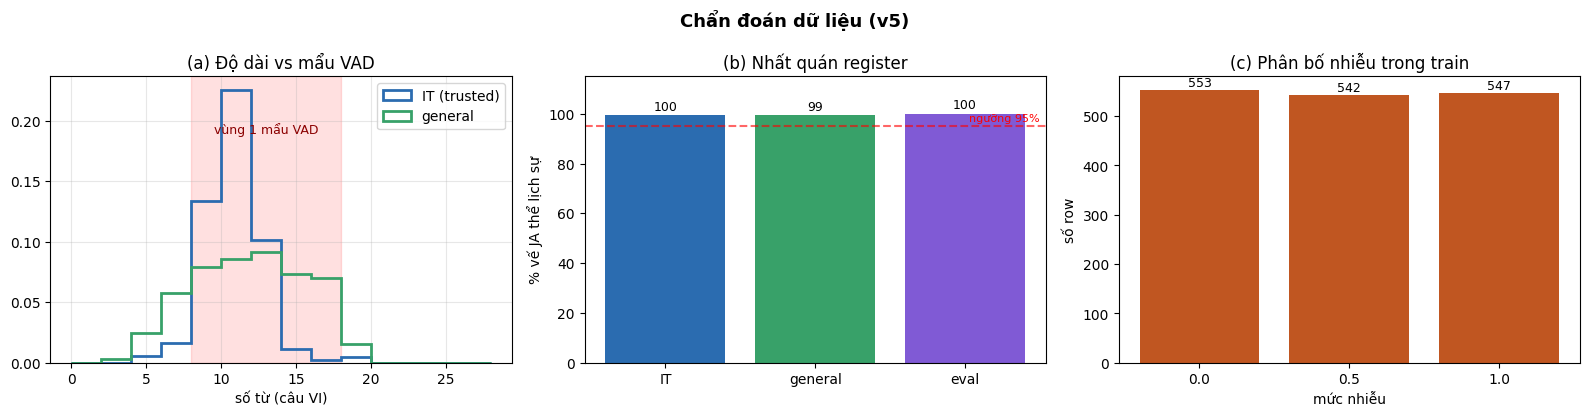

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
fig.suptitle("Chẩn đoán dữ liệu (v5)", fontsize=13, fontweight="bold")

ax = axes[0]
for name, pairs, c in [("IT (trusted)", train_trusted, "#2b6cb0"),
                       ("general", gen_pairs, "#38a169")]:
    if pairs:
        ax.hist([len(v.split()) for v, _ in pairs], bins=np.arange(0, 30, 2),
                histtype="step", linewidth=2, label=name, color=c, density=True)
ax.axvspan(8, 18, alpha=0.12, color="red")
ax.text(13, ax.get_ylim()[1]*0.8, "vùng 1 mẩu VAD", ha="center", fontsize=9, color="darkred")
ax.set_xlabel("số từ (câu VI)"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("(a) Độ dài vs mẩu VAD")

ax = axes[1]
POLITE = re.compile(r"(です|ます|ません|ました|でした|ください|ましょう|ございます"
                    r"|ますか|ですか|ましたか|ませんか|ましょうか|でしょうか)[。！？]*$")
names, vals = [], []
for name, pairs in [("IT", train_trusted), ("general", gen_pairs), ("eval", eval_pairs)]:
    if pairs:
        names.append(name)
        vals.append(100 * sum(1 for _, j in pairs if POLITE.search(j)) / len(pairs))
b = ax.bar(names, vals, color=["#2b6cb0", "#38a169", "#805ad5"])
ax.set_ylim(0, 115); ax.set_ylabel("% vế JA thể lịch sự")
ax.axhline(95, ls="--", color="red", alpha=0.6)
ax.text(len(names)-0.5, 97, "ngưỡng 95%", fontsize=8, color="red", ha="right")
for r, v in zip(b, vals): ax.text(r.get_x()+r.get_width()/2, v+2, f"{v:.0f}", ha="center", fontsize=9)
ax.set_title("(b) Nhất quán register")

ax = axes[2]
lv = {}
for r in train_dataset:
    lv[r["level"]] = lv.get(r["level"], 0) + 1
ks = sorted(lv)
ax.bar([str(k) for k in ks], [lv[k] for k in ks], color="#c05621")
ax.set_xlabel("mức nhiễu"); ax.set_ylabel("số row")
ax.set_title("(c) Phân bố nhiễu trong train")
for i, k in enumerate(ks): ax.text(i, lv[k]+8, str(lv[k]), ha="center", fontsize=9)

plt.tight_layout(); plt.show()

In [ ]:
import torch
from transformers import (M2M100ForConditionalGeneration, M2M100Tokenizer,
                          Seq2SeqTrainingArguments, Seq2SeqTrainer,
                          DataCollatorForSeq2Seq, EarlyStoppingCallback)
from peft import LoraConfig, get_peft_model, TaskType

model_id = "facebook/m2m100_418M"
tokenizer = M2M100Tokenizer.from_pretrained(model_id)
model = M2M100ForConditionalGeneration.from_pretrained(model_id)

lora_config = LoraConfig(
    r=24, lora_alpha=48,
    target_modules=["q_proj", "k_proj", "v_proj", "out_proj", "fc1", "fc2"],
    lora_dropout=0.1, bias="none", task_type=TaskType.SEQ_2_SEQ_LM,
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

MAX_LEN = 128

def preprocess(ex):
    # M2M100 phải set src_lang TRƯỚC khi encode (chèn token ngôn ngữ vào đầu chuỗi)
    tokenizer.src_lang = ex["src_lang"]
    mi = tokenizer(ex["src_text"], max_length=MAX_LEN, truncation=True)
    tokenizer.tgt_lang = ex["tgt_lang"]
    mi["labels"] = tokenizer(text_target=ex["tgt_text"], max_length=MAX_LEN,
                             truncation=True)["input_ids"]
    return mi

tokenized_train      = train_dataset.map(preprocess,    remove_columns=train_dataset.column_names)
tokenized_eval       = eval_dataset_raw.map(preprocess, remove_columns=eval_dataset_raw.column_names)
tokenized_eval_noisy = eval_noisy_raw.map(preprocess,   remove_columns=eval_noisy_raw.column_names)

# PeftModel bọc ngoài làm DataCollatorForSeq2Seq không thấy
# prepare_decoder_input_ids_from_labels -> nó bỏ qua bước dựng decoder_input_ids.
collator_model = model.get_base_model() if hasattr(model, "get_base_model") else model
data_collator = DataCollatorForSeq2Seq(tokenizer, model=collator_model)

print(f"\nTrain {len(tokenized_train)} | Eval sạch {len(tokenized_eval)} | Eval nhiễu {len(tokenized_eval_noisy)}")
print("Collator dùng:", type(collator_model).__name__)

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

trainable params: 12,976,128 || all params: 496,881,664 || trainable%: 2.6115


Map:   0%|          | 0/1642 [00:00<?, ? examples/s]

Map:   0%|          | 0/206 [00:00<?, ? examples/s]

Map:   0%|          | 0/206 [00:00<?, ? examples/s]


Train 1642 | Eval sạch 206 | Eval nhiễu 206
Collator dùng: M2M100ForConditionalGeneration


In [ ]:
from torch.utils.data import DataLoader

dev = "cuda" if torch.cuda.is_available() else "cpu"
model.to(dev)

cols = tokenized_train.column_names
leftover = [c for c in cols if c not in ("input_ids", "attention_mask", "labels")]
if leftover:
    raise RuntimeError(f"Còn cột thừa {leftover} — collator sẽ ép thành tensor và nổ.")

batch = next(iter(DataLoader(tokenized_train.select(range(4)), batch_size=2, collate_fn=data_collator)))
print("Khoá trong batch:", {k: tuple(v.shape) for k, v in batch.items()})
if "labels" not in batch and "decoder_input_ids" not in batch:
    raise RuntimeError("Batch thiếu labels lẫn decoder_input_ids -> decoder sẽ nổ.")

model.train()
out = model(**{k: v.to(dev) for k, v in batch.items()})
out.loss.backward(); model.zero_grad(set_to_none=True)
print(f"\n✅ forward + backward OK — loss = {out.loss.item():.4f}")

Khoá trong batch: {'input_ids': (2, 25), 'attention_mask': (2, 25), 'labels': (2, 27)}

✅ forward + backward OK — loss = 2.6134


In [ ]:
EPOCHS = 6          # v4: eval_loss phẳng từ epoch 4, early stop bắn ở 2849/3256
BS = 8
steps_per_epoch = -(-len(tokenized_train) // BS)
total_steps = steps_per_epoch * EPOCHS
warmup_steps = max(10, int(total_steps * 0.06))
print(f"steps/epoch {steps_per_epoch} | total {total_steps} | warmup {warmup_steps}")

args = Seq2SeqTrainingArguments(
    output_dir="./m2m418-lora-v6",
    learning_rate=2.5e-4,
    lr_scheduler_type="cosine",
    warmup_steps=warmup_steps,
    per_device_train_batch_size=BS,
    per_device_eval_batch_size=16,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
    # KHÔNG bật label_smoothing_factor: Trainer pop 'labels' khỏi inputs ->
    # M2M100 không dựng được decoder_input_ids -> ValueError. Lợi ~0.3 chrF.
    logging_steps=20,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
)

trainer = Seq2SeqTrainer(
    model=model, args=args,
    train_dataset=tokenized_train,
    # 🔴 SỬA v5: chọn checkpoint theo eval NHIỄU.
    # App chạy trên output ASR, không phải văn bản có dấu câu đầy đủ.
    eval_dataset=tokenized_eval_noisy,
    data_collator=data_collator,
    processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()

steps/epoch 206 | total 1236 | warmup 74


Epoch,Training Loss,Validation Loss
1,2.074239,1.756667
2,1.620667,1.607883
3,1.254539,1.551314
4,1.163467,1.525704
5,0.907204,1.526298
6,0.911200,1.527216


TrainOutput(global_step=1236, training_loss=1.3361068165418013, metrics={'train_runtime': 317.8461, 'train_samples_per_second': 30.996, 'train_steps_per_second': 3.889, 'total_flos': 466304977797120.0, 'train_loss': 1.3361068165418013, 'epoch': 6.0})

In [ ]:
import json, os, shutil

os.makedirs("./adapter_best_v6", exist_ok=True)
model.save_pretrained("./adapter_best_v6")
tokenizer.save_pretrained("./adapter_best_v6")
json.dump(trainer.state.log_history, open("./adapter_best_v6/log_history.json", "w"),
          ensure_ascii=False, indent=1)
size = sum(os.path.getsize(f"./adapter_best_v6/{f}") for f in os.listdir("./adapter_best_v6")) / 1e6
print(f"✅ adapter_best_v6 ({size:.1f} MB)")

# Bỏ comment nếu muốn sống sót khi /content bị xoá:
# from google.colab import drive; drive.mount("/content/drive")
# shutil.make_archive("/content/drive/MyDrive/m2m418_adapter_v6", "zip", "./adapter_best_v6")

✅ adapter_best_v6 (58.1 MB)


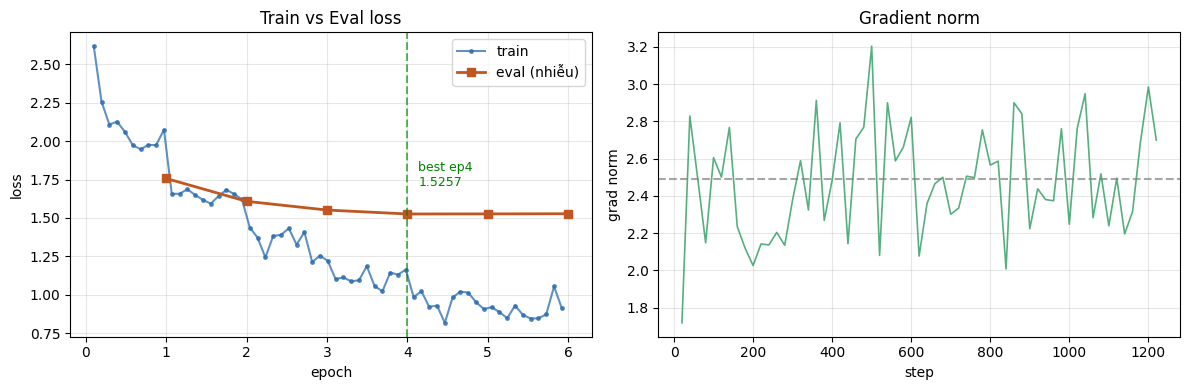

  epoch 1: 1.7567
  epoch 2: 1.6079
  epoch 3: 1.5513
  epoch 4: 1.5257  ← best
  epoch 5: 1.5263
  epoch 6: 1.5272

⚠️  3 epoch cuối chênh <0.01 -> data đã bão hoà, thêm epoch vô ích.
    Muốn tăng nữa thì phải THÊM DATA, không phải thêm epoch.


In [ ]:
import matplotlib.pyplot as plt, numpy as np

h = trainer.state.log_history
tr = [(x["epoch"], x["loss"]) for x in h if "loss" in x and "eval_loss" not in x]
ev = [(x["epoch"], x["eval_loss"]) for x in h if "eval_loss" in x]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
if tr: ax.plot(*zip(*tr), label="train", color="#2b6cb0", marker="o", ms=2.5, alpha=.75)
if ev:
    xs, ys = zip(*ev)
    ax.plot(xs, ys, label="eval (nhiễu)", color="#c05621", marker="s", ms=6, lw=2)
    i = int(np.argmin(ys)); ax.axvline(xs[i], ls="--", color="green", alpha=.6)
    ax.annotate(f"best ep{xs[i]:.0f}\n{ys[i]:.4f}", xy=(xs[i], ys[i]),
                xytext=(8, 20), textcoords="offset points", fontsize=9, color="green")
ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.legend(); ax.grid(alpha=.3)
ax.set_title("Train vs Eval loss")

ax = axes[1]
g = [(x["step"], x["grad_norm"]) for x in h if "grad_norm" in x]
if g:
    ax.plot(*zip(*g), color="#38a169", lw=1.2, alpha=.85)
    ax.axhline(float(np.median([y for _, y in g])), ls="--", color="gray", alpha=.7)
ax.set_xlabel("step"); ax.set_ylabel("grad norm"); ax.grid(alpha=.3); ax.set_title("Gradient norm")
plt.tight_layout(); plt.show()

if ev:
    best = min(y for _, y in ev)
    for e, l in ev: print(f"  epoch {e:.0f}: {l:.4f}{'  ← best' if l == best else ''}")
    tail = [l for _, l in ev[-3:]]
    if max(tail) - min(tail) < 0.01:
        print("\n⚠️  3 epoch cuối chênh <0.01 -> data đã bão hoà, thêm epoch vô ích.")
        print("    Muốn tăng nữa thì phải THÊM DATA, không phải thêm epoch.")

In [ ]:
import sacrebleu, numpy as np, torch

RESULTS = {}

@torch.no_grad()
def gen_batch(texts, src, tgt, bs=16):
    outs = []; model.eval()
    for i in range(0, len(texts), bs):
        tokenizer.src_lang = src
        enc = tokenizer(texts[i:i+bs], return_tensors="pt", padding=True,
                        truncation=True, max_length=128).to(model.device)
        o = model.generate(**enc, forced_bos_token_id=tokenizer.get_lang_id(tgt),
                           max_length=128, num_beams=4, early_stopping=True,
                           no_repeat_ngram_size=3, repetition_penalty=1.05)
        outs += tokenizer.batch_decode(o, skip_special_tokens=True)
    return outs

def boot_ci(sent, n=1000, seed=0):
    """CI 95% của chrF trung bình câu. Không bằng corpus chrF nhưng đủ để
    biết chênh lệch giữa hai lần train có thật hay chỉ là nhiễu."""
    r = np.random.default_rng(seed); a = np.asarray(sent)
    m = [a[r.integers(0, len(a), len(a))].mean() for _ in range(n)]
    return np.percentile(m, 2.5), np.percentile(m, 97.5)

def score(ds, label):
    print(f"\n===== {label} =====")
    for src, tgt in [("ja", "vi"), ("vi", "ja")]:
        sub = [r for r in ds if r["src_lang"] == src]
        if not sub: continue
        srcs = [r["src_text"] for r in sub]; refs = [r["tgt_text"] for r in sub]
        preds = gen_batch(srcs, src, tgt)
        chrf = sacrebleu.corpus_chrf(preds, [refs]).score
        try:
            bleu = sacrebleu.corpus_bleu(preds, [refs],
                                         tokenize="ja-mecab" if tgt == "ja" else "13a").score
        except Exception:
            bleu = sacrebleu.corpus_bleu(preds, [refs], tokenize="char").score
        sent = [sacrebleu.sentence_chrf(p, [r]).score for p, r in zip(preds, refs)]
        lo, hi = boot_ci(sent)
        RESULTS[(label, src, tgt)] = dict(chrf=chrf, bleu=bleu, sent=sent,
                                          srcs=srcs, refs=refs, preds=preds, ci=(lo, hi))
        print(f"  {src}→{tgt}:  chrF {chrf:5.2f}  BLEU {bleu:5.2f}  "
              f"| CI95 câu [{lo:.1f}, {hi:.1f}]  (n={len(sub)})")

score(eval_dataset_raw, "SẠCH")
score(eval_noisy_raw,   "NHIỄU")

print("\n" + "=" * 66)
for src, tgt in [("ja", "vi"), ("vi", "ja")]:
    c = RESULTS.get(("SẠCH", src, tgt), {}).get("chrf")
    n = RESULTS.get(("NHIỄU", src, tgt), {}).get("chrf")
    if c and n:
        print(f"{src}→{tgt}: sạch {c:.2f} → nhiễu {n:.2f}  (mất {c-n:.2f} = {(c-n)/c*100:.1f}%)")

# ---- v6: so với mốc v5 đã đo (chép tay từ lần chạy trước) ----
V5_BASELINE = {  # (label, src, tgt) -> chrF
    ("SẠCH", "ja", "vi"): 48.64, ("NHIỄU", "ja", "vi"): 48.64,
    ("SẠCH", "vi", "ja"): 44.07, ("NHIỄU", "vi", "ja"): 38.53,
}
print("\n" + "=" * 66); print("SO VỚI V5 (bootstrap CI ở trên mới là thứ quyết định chênh lệch có thật)"); print("=" * 66)
for label in ("SẠCH", "NHIỄU"):
    for src, tgt in [("ja", "vi"), ("vi", "ja")]:
        v6 = RESULTS.get((label, src, tgt), {}).get("chrf")
        v5 = V5_BASELINE.get((label, src, tgt))
        if v6 and v5:
            d = v6 - v5
            print(f"  {label:6s} {src}→{tgt}: v5 {v5:5.2f} -> v6 {v6:5.2f}  ({'+' if d >= 0 else ''}{d:.2f})")
print("Cột NHIỄU mới phản ánh app thật.")
print("⚠️  Bề rộng CI cho biết chênh lệch bao nhiêu điểm mới ĐÁNG TIN.")
print("=" * 66)


===== SẠCH =====
  ja→vi:  chrF 49.53  BLEU 27.42  | CI95 câu [46.2, 52.7]  (n=103)
  vi→ja:  chrF 45.99  BLEU 52.59  | CI95 câu [42.0, 49.0]  (n=103)

===== NHIỄU =====
  ja→vi:  chrF 49.53  BLEU 27.42  | CI95 câu [46.2, 52.7]  (n=103)
  vi→ja:  chrF 38.92  BLEU 44.85  | CI95 câu [35.0, 42.0]  (n=103)

ja→vi: sạch 49.53 → nhiễu 49.53  (mất 0.00 = 0.0%)
vi→ja: sạch 45.99 → nhiễu 38.92  (mất 7.07 = 15.4%)

SO VỚI V5 (bootstrap CI ở trên mới là thứ quyết định chênh lệch có thật)
  SẠCH   ja→vi: v5 48.64 -> v6 49.53  (+0.89)
  SẠCH   vi→ja: v5 44.07 -> v6 45.99  (+1.92)
  NHIỄU  ja→vi: v5 48.64 -> v6 49.53  (+0.89)
  NHIỄU  vi→ja: v5 38.53 -> v6 38.92  (+0.39)
Cột NHIỄU mới phản ánh app thật.
⚠️  Bề rộng CI cho biết chênh lệch bao nhiêu điểm mới ĐÁNG TIN.


In [ ]:
import re

POLITE = re.compile(r"(です|ます|ません|ました|でした|ください|ましょう|ございます"
                    r"|ますか|ですか|ましたか|ませんか|ましょうか|でしょうか)[。！？]*$")

# ---- (1) Độ nhất quán thể lịch sự trên toàn bộ output vi→ja ----
print("=" * 66); print("(1) REGISTER — % output vi→ja ở thể lịch sự"); print("=" * 66)
for label in ("SẠCH", "NHIỄU"):
    r = RESULTS.get((label, "vi", "ja"))
    if r:
        pol = 100 * sum(1 for p in r["preds"] if POLITE.search(p.strip())) / len(r["preds"])
        ref = 100 * sum(1 for p in r["refs"]  if POLITE.search(p.strip())) / len(r["refs"])
        flag = "✅" if pol >= 90 else "🔴"
        print(f"  {label:6s} model {pol:5.1f}%   |  chuẩn {ref:5.1f}%   {flag}")
print("  Dưới 90% = đối tác Nhật sẽ thấy thất lễ. chrF không phạt lỗi này.")

# ---- (2) Contrast set: các lỗi CỤ THỂ quan sát được ở v4 ----
# (nguồn, src, tgt, PHẢI có, KHÔNG được có, mô tả)
# ⚠️ QUY TẮC THÊM CASE: câu nguồn KHÔNG được trùng bất kỳ câu nào trong data
# train (kể cả new_it_pairs_v6.jsonl) — trùng thì chỉ đo trí nhớ, không đo
# generalize. Bản v6 lần 1 dính 4 case nhiễm kiểu này, đã thay hết bên dưới.
CONTRAST = [
 ("Phần này ai rảnh nhận giúp không, em đang ôm hơi nhiều.", "vi", "ja",
  r"(手伝|助け)", r"抱擁", "ôm việc ≠ 抱擁 (ôm ấp)"),
 ("Mọi người đồng ý thì mình tiến hành luôn nhé.", "vi", "ja",
  r"(ましょう)", r"てください", "rủ rê ≠ ra lệnh"),
 ("Cổng 8000 đang bị chiếm.", "vi", "ja",
  r"(使用中|使われて|使用され|埋まって)", r"占領", "port bận ≠ chiếm đóng quân sự"),
 ("Phân quyền chưa chặt, user thường vào được trang admin.", "vi", "ja",
  r"権限", r"特権", "権限 (quyền) ≠ 特権 (đặc quyền)"),
 ("Do đổi yêu cầu giữa chừng nên tiến độ chung bị ảnh hưởng.", "vi", "ja",
  r"(途中|変更)", r"中間要件", "đổi giữa chừng ≠ 'yêu cầu trung gian'"),
 ("9 giờ sáng mai họp standup nhé mọi người.", "vi", "ja",
  r"9時", r"ごろ", "không được thêm 'khoảng' vào giờ họp"),
 ("Mình bàn lại deadline vào chiều mai nhé.", "vi", "ja",
  r"(ましょう|ませんか)", r"しろ", "giữ thể lịch sự"),
 ("少し抱えすぎているので、余裕がある人に手伝ってほしいです。", "ja", "vi",
  r"(giúp|hỗ trợ)", r"muốn giúp đỡ", "~てほしい: NGƯỜI NÓI cần được giúp"),
 ("権限制御が甘く、一般ユーザーが管理画面に入れてしまいます。", "ja", "vi",
  r"(phân quyền|quyền)", r"mềm", "甘い = lỏng lẻo, không phải 'mềm'"),
 ("この件は明日までに対応していただけますか。", "ja", "vi",
  r"(giúp|nhờ|được không|nhé)", r"^Tôi sẽ", "nhờ vả ≠ tự nhận việc"),
 ("サーバーのメモリーが足りないので、スケールアップしてください。", "ja", "vi",
  r"(memory|bộ nhớ|RAM)", r"kỷ niệm", "メモリー = bộ nhớ"),
 ("レビューのコメントを反映しました。", "ja", "vi",
  r"(review|comment|nhận xét|góp ý)", r"bình luận phim", "review code"),

 # ---- v6 lần 2: 4 case ĐỀU diễn đạt khác data train, đo generalize thật ----
 ("恐れ入りますが、こちらの内容を来週までにご確認いただくことは可能でしょうか。", "ja", "vi",
  r"(giúp|anh|chị|được không|nhé|ạ)", r"^(Tôi|Em) sẽ",
  "kính ngữ lồng でしょうか (diễn đạt khác) -- nhờ vả ≠ tự nhận việc"),
 ("Chị copy giúp em file config đó sang server mới với.", "vi", "ja",
  r"(コピー|していただけ)", r"手伝って",
  "giúp+động từ cụ thể (diễn đạt khác) ≠ 手伝ってください chung chung"),
 ("Nếu cả nhóm không ai có ý kiến khác thì mình chốt kế hoạch này nhé.", "vi", "ja",
  r"(ましょう)", r"てください",
  "rủ rê tập thể (diễn đạt khác) ≠ ra lệnh"),
 ("Tuyệt đối không được tắt server trong giờ làm việc, nhớ kỹ điều này.", "vi", "ja",
  r"(ないでください|てください)", r"ましょう",
  "case đối chứng (diễn đạt khác) -- lệnh cấm không được biến thành rủ rê"),
]

print("\n" + "=" * 66); print("(2) CONTRAST SET — các lỗi cụ thể của v4"); print("=" * 66)
passed = 0
for srct, s, t, must, mustnt, desc in CONTRAST:
    out = gen_batch([srct], s, t)[0]
    ok_have = bool(re.search(must, out, re.I))
    ok_not  = not re.search(mustnt, out, re.I)
    ok = ok_have and ok_not
    passed += ok
    print(f"  {'✅' if ok else '🔴'} [{s}→{t}] {desc}")
    if not ok:
        print(f"       nguồn: {srct}")
        print(f"       model: {out}")
        if not ok_have: print(f"       thiếu: /{must}/")
        if not ok_not:  print(f"       dính : /{mustnt}/")
print(f"\n  ĐẠT {passed}/{len(CONTRAST)}")
print("  Đây là thước đo nhạy hơn chrF nhiều cho lỗi đại từ / register / thuật ngữ.")
print("  Bổ sung thêm case mỗi lần gặp lỗi mới trong log thật.")

(1) REGISTER — % output vi→ja ở thể lịch sự
  SẠCH   model  99.0%   |  chuẩn 100.0%   ✅
  NHIỄU  model  98.1%   |  chuẩn 100.0%   ✅
  Dưới 90% = đối tác Nhật sẽ thấy thất lễ. chrF không phạt lỗi này.

(2) CONTRAST SET — các lỗi cụ thể của v4
  ✅ [vi→ja] ôm việc ≠ 抱擁 (ôm ấp)
  🔴 [vi→ja] rủ rê ≠ ra lệnh
       nguồn: Mọi người đồng ý thì mình tiến hành luôn nhé.
       model: 皆同意したら、進めてください。
       thiếu: /(ましょう)/
       dính : /てください/
  🔴 [vi→ja] port bận ≠ chiếm đóng quân sự
       nguồn: Cổng 8000 đang bị chiếm.
       model: ポート8000は占領中です。
       thiếu: /(使用中|使われて|使用され|埋まって)/
       dính : /占領/
  ✅ [vi→ja] 権限 (quyền) ≠ 特権 (đặc quyền)
  ✅ [vi→ja] đổi giữa chừng ≠ 'yêu cầu trung gian'
  ✅ [vi→ja] không được thêm 'khoảng' vào giờ họp
  ✅ [vi→ja] giữ thể lịch sự
  ✅ [ja→vi] ~てほしい: NGƯỜI NÓI cần được giúp
  ✅ [ja→vi] 甘い = lỏng lẻo, không phải 'mềm'
  ✅ [ja→vi] nhờ vả ≠ tự nhận việc
  ✅ [ja→vi] メモリー = bộ nhớ
  ✅ [ja→vi] review code
  ✅ [ja→vi] kính ngữ lồng でしょうか (diễn đạt khác) -- nhờ vả 

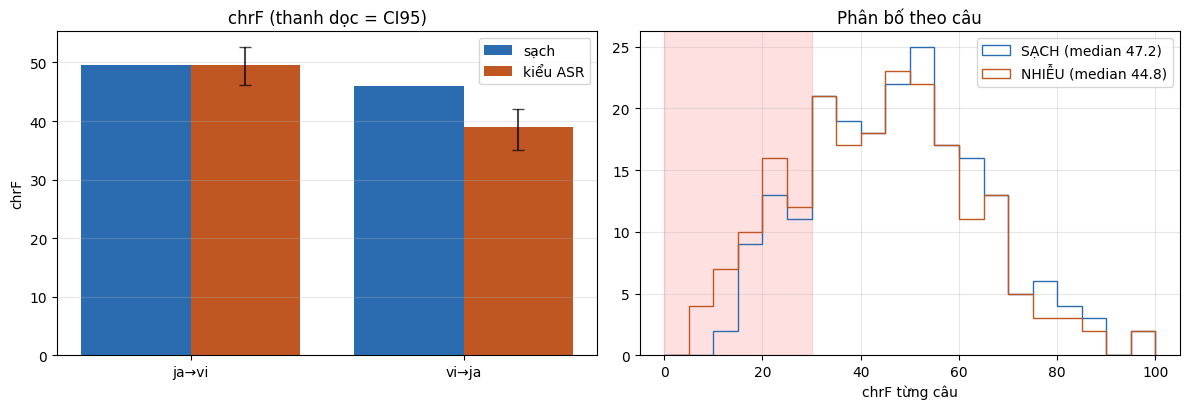

8 CÂU TỆ NHẤT trên eval NHIỄU

[vi→ja] chrF=5.8
  nguồn : danh sạch kết xuất trậm khi co nhiêu bản ghi
  chuẩn : このリストは、レコードが多いと描画が遅くなります。
  model : 記録が切れたら、出力が遅いので、名称を清潔にしてください。

[vi→ja] chrF=7.3
  nguồn : mình đê một buôi buffer phòng khi phát sinh ngoài dự kiến
  chuẩn : 想定外のことに備えて、予備の時間を1コマ確保しましょう。
  model : 予想外の時点で、部屋のバッファーを作ってください。

[vi→ja] chrF=7.4
  nguồn : giữ liệu tra về cẩn sắp xếp theo thời gian mới nhất
  chuẩn : 返すデータは新しい順に並べる必要があります。
  model : データを確認して、最新のタイミングで整理してください。

[vi→ja] chrF=9.2
  nguồn : phấn nay ai ranh nhận giúp không em đang ôm hơi nhiều
  chuẩn : 少し抱えすぎているので、余裕がある人に手伝ってほしいです。
  model : 誰が助かるのでしょうか? 抱きしめていますか。

[vi→ja] chrF=10.6
  nguồn : do đổi yêu cầu giựa trừng nên tiến độ chung bị ạnh hưởng
  chuẩn : 途中で要件が変わったため、全体の進捗に影響が出ています。
  model : 要件の変更により、共同進捗が不適切になります。

[vi→ja] chrF=11.3
  nguồn : vể vấn đề em xin phép xac lhận lại rồi trạ sau
  chuẩn : この件については、確認のうえ改めてご回答いたします。
  model : 問題があれば、XACの誤解をお願いします。後で確認してください。

[vi→ja] chrF=11.7
  nguồn : cảm ơn mỏ

In [ ]:
import matplotlib.pyplot as plt, numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
dirs = [("ja", "vi"), ("vi", "ja")]
ax = axes[0]
x = np.arange(len(dirs))
clean = [RESULTS.get(("SẠCH", s, t), {}).get("chrf", 0) for s, t in dirs]
noisy = [RESULTS.get(("NHIỄU", s, t), {}).get("chrf", 0) for s, t in dirs]
ax.bar(x-0.2, clean, 0.4, label="sạch", color="#2b6cb0")
ax.bar(x+0.2, noisy, 0.4, label="kiểu ASR", color="#c05621")
for s, t in dirs:
    r = RESULTS.get(("NHIỄU", s, t))
    if r:
        i = dirs.index((s, t)); lo, hi = r["ci"]
        ax.errorbar(i+0.2, r["chrf"], yerr=[[r["chrf"]-lo], [hi-r["chrf"]]],
                    fmt="none", ecolor="black", capsize=4, alpha=.7)
ax.set_xticks(x); ax.set_xticklabels([f"{s}→{t}" for s, t in dirs])
ax.set_ylabel("chrF"); ax.legend(); ax.grid(axis="y", alpha=.3)
ax.set_title("chrF (thanh dọc = CI95)")

ax = axes[1]
for lab, c in [("SẠCH", "#2b6cb0"), ("NHIỄU", "#c05621")]:
    a = [x for s, t in dirs for x in RESULTS.get((lab, s, t), {}).get("sent", [])]
    if a: ax.hist(a, bins=np.arange(0, 105, 5), histtype="step", lw=2,
                  label=f"{lab} (median {np.median(a):.1f})", color=c)
ax.axvspan(0, 30, alpha=.12, color="red")
ax.set_xlabel("chrF từng câu"); ax.legend(); ax.grid(alpha=.3)
ax.set_title("Phân bố theo câu")
plt.tight_layout(); plt.show()

print("=" * 70); print("8 CÂU TỆ NHẤT trên eval NHIỄU"); print("=" * 70)
worst = []
for s, t in dirs:
    r = RESULTS.get(("NHIỄU", s, t))
    if r:
        worst += [(sc, f"{s}→{t}", a, b, c)
                  for sc, a, b, c in zip(r["sent"], r["srcs"], r["refs"], r["preds"])]
worst.sort(key=lambda z: z[0])
for sc, d, src, ref, pred in worst[:8]:
    print(f"\n[{d}] chrF={sc:.1f}\n  nguồn : {src}\n  chuẩn : {ref}\n  model : {pred}")

In [ ]:
import torch

@torch.no_grad()
def dich(text, src, tgt):
    tokenizer.src_lang = src
    enc = tokenizer(text, return_tensors="pt").to(model.device)
    o = model.generate(**enc, forced_bos_token_id=tokenizer.get_lang_id(tgt),
                       max_length=128, num_beams=4, early_stopping=True,
                       no_repeat_ngram_size=3, repetition_penalty=1.05)
    return tokenizer.batch_decode(o, skip_special_tokens=True)[0]

model.eval()
_r = random.Random(11)

print("=" * 76); print("JA → VI"); print("=" * 76)
for t in ["決済部分のバグを修正してください。",
          "サーバーのメモリーが足りないので、スケールアップが必要です。",
          "devブランチにプッシュしたのでレビューをお願いします。",
          "このAPIはページネーションが必要です。",
          "会議の日程を来週に変更してもよろしいでしょうか。"]:
    print(f"  sạch    : {t}\n          → {dich(t, 'ja', 'vi')}")
    n = noise_ja(t)
    print(f"  kiểu ASR: {n}\n          → {dich(n, 'ja', 'vi')}\n")

print("=" * 76); print("VI → JA"); print("=" * 76)
for t in ["Sửa con bug ở phần thanh toán đi.",
          "Cổng 8000 đang bị chiếm.",
          "Cần tạo một nhánh mới từ main để làm feature này.",
          "Deadline cuối tháng hơi gấp, mình bàn lại nhé.",
          "Phân quyền chưa chặt, user thường vào được trang admin."]:
    print(f"  sạch    : {t}\n          → {dich(t, 'vi', 'ja')}")
    n = noise_vi(t, _r, 1.0)
    print(f"  kiểu ASR: {n}\n          → {dich(n, 'vi', 'ja')}\n")

print("=" * 76); print("v6 -- soi nhanh 2 pattern vừa thêm data"); print("=" * 76)
for t in ["恐れ入りますが、その資料を後ほど共有していただけますでしょうか。"]:
    print(f"  ja→vi: {t}\n          → {dich(t, 'ja', 'vi')}")
for t in ["Nhờ chị gửi lại file báo cáo giúp em với.",
          "Mọi người thấy ổn thì mình bắt đầu triển khai luôn nhé."]:
    print(f"  vi→ja: {t}\n          → {dich(t, 'vi', 'ja')}")
print()

print("=" * 76)
print("MẨU BỊ VAD CẮT NGANG — nhắc lại vì sao KHÔNG dịch partial tiếng Nhật")
print("=" * 76)
for frag in ["この部分は納品前に", "会議の日程を", "cái api này cần thêm", "deadline cuối tháng hơi"]:
    s = "ja" if JP_RE.search(frag) else "vi"
    print(f"  {frag}\n    → {dich(frag, s, 'vi' if s == 'ja' else 'ja')}")
print("\nTiếng Nhật là SOV: động từ/phủ định/thể lịch sự nằm CUỐI câu.")
print("Dịch nửa câu ja luôn ra rác -> ở server chỉ dịch khi is_final=True.")

JA → VI
  sạch    : 決済部分のバグを修正してください。
          → Fix bug ở phần thanh toán nhé.
  kiểu ASR: 決済部分のバグを修正してください
          → Fix bug ở phần thanh toán nhé.

  sạch    : サーバーのメモリーが足りないので、スケールアップが必要です。
          → Bộ nhớ server thiếu, cần scale up.
  kiểu ASR: サーバーのメモリーが足りないのでスケールアップが必要です
          → Bộ nhớ server thiếu, cần scale up.

  sạch    : devブランチにプッシュしたのでレビューをお願いします。
          → Push lên nhánh dev rồi, em review giúp nhé.
  kiểu ASR: devブランチにプッシュしたのでレビューをお願いします
          → Mình push lên nhánh dev rồi, em review giúp nhé.

  sạch    : このAPIはページネーションが必要です。
          → API này cần thiết lập trang.
  kiểu ASR: このAPIはページネーションが必要です
          → API này cần thiết lập trang.

  sạch    : 会議の日程を来週に変更してもよろしいでしょうか。
          → Chị đổi lịch họp sang tuần sau được không ạ.
  kiểu ASR: 会議の日程を来週に変更してもよろしいでしょうか
          → Chị đổi lịch họp sang tuần sau được không ạ.

VI → JA
  sạch    : Sửa con bug ở phần thanh toán đi.
          → 決済部分のバグを修正してください。
  kiểu ASR: sửa con bug ở phần thanh toán đi
   

In [ ]:
merged = model.merge_and_unload()      # sau lệnh này biến `model` không dùng lại được
merged.save_pretrained("m2m418-it-merged-v6")
tokenizer.save_pretrained("m2m418-it-merged-v6")

import os
for f in sorted(os.listdir("m2m418-it-merged-v6")):
    print(f"  {f:32s} {os.path.getsize(f'm2m418-it-merged-v6/{f}')/1e6:8.2f} MB")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  added_tokens.json                    0.00 MB
  config.json                          0.00 MB
  generation_config.json               0.00 MB
  model.safetensors                 1935.68 MB
  sentencepiece.bpe.model              2.42 MB
  tokenizer_config.json                0.02 MB
  vocab.json                           3.71 MB


In [ ]:
!pip install -q ctranslate2

import os, subprocess

SRC, OUT = "m2m418-it-merged-v6", "m2m100_418M_int8_v6"
# v6: đặt tên khác v5 có chủ đích -- so sánh A/B với bản đang chạy production
# (backend/models/m2m100_418M_int8/) trước, xác nhận tốt hơn rồi mới đổi tên/
# ghi đè thư mục production.
CANDIDATES = ["sentencepiece.bpe.model", "vocab.json", "tokenizer_config.json",
              "special_tokens_map.json", "added_tokens.json", "tokenizer.json"]
present = [f for f in CANDIDATES if os.path.exists(f"{SRC}/{f}")]
print("copy :", present)
print("thiếu:", [f for f in CANDIDATES if f not in present], "(bình thường ở transformers v5)")

if "tokenizer_config.json" not in present:
    raise RuntimeError("Thiếu tokenizer_config.json — chạy lại CELL 13.")

subprocess.run(["ct2-transformers-converter", "--model", SRC, "--output_dir", OUT,
                "--quantization", "int8", "--force", "--copy_files", *present], check=True)
print("✅ Convert xong")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.5/39.5 MB 20.6 MB/s eta 0:00:00
copy : ['sentencepiece.bpe.model', 'vocab.json', 'tokenizer_config.json', 'added_tokens.json']
thiếu: ['special_tokens_map.json', 'tokenizer.json'] (bình thường ở transformers v5)
✅ Convert xong


In [ ]:
import os, ctranslate2
from transformers import AutoTokenizer

for f in sorted(os.listdir(OUT)):
    print(f"  {f:30s} {os.path.getsize(f'{OUT}/{f}')/1e6:8.2f} MB")
lack = [f for f in ["model.bin", "config.json", "shared_vocabulary.json"]
        if not os.path.exists(f"{OUT}/{f}")]
if lack:
    raise RuntimeError(f"Thiếu file lõi {lack} — convert hỏng.")

tok = AutoTokenizer.from_pretrained(OUT)          # LOCAL, không mạng
tr  = ctranslate2.Translator(OUT, device="cpu", compute_type="int8")

def dich_ct2(text, src, tgt):
    tok.src_lang = src
    st = tok.convert_ids_to_tokens(tok.encode(text))
    prefix = ([tok.lang_code_to_token[tgt]] if hasattr(tok, "lang_code_to_token")
              else [f"__{tgt}__"])
    # max_decoding_length: hệ số theo CHIỀU. ja→vi nở token mạnh (kanji dày ->
    # tiếng Việt tách âm tiết), vi→ja thì ngược lại. Bản cũ dùng chung 2.5 cho
    # cả hai -> ja→vi bị cắt cụt, vi→ja quá lỏng.
    mult = 4.0 if (src, tgt) == ("ja", "vi") else 2.0
    res = tr.translate_batch([st], target_prefix=[prefix], beam_size=4,
                             max_decoding_length=min(128, int(len(st) * mult) + 12),
                             repetition_penalty=1.1, no_repeat_ngram_size=3)
    return tok.decode(tok.convert_tokens_to_ids(res[0].hypotheses[0][1:]),
                      skip_special_tokens=True).strip()

print("\n--- CT2 INT8 trên CPU ---")
for t, s, g in [("この部分は納品前に再確認が必要です。", "ja", "vi"),
                ("サーバーのメモリーが足りません", "ja", "vi"),
                ("Cần tạo một nhánh mới từ main.", "vi", "ja"),
                ("cổng 8000 đang bị chiếm", "vi", "ja")]:
    print(f"  [{s}→{g}] {t}\n            → {dich_ct2(t, s, g)}")

!zip -qr {OUT}.zip {OUT}
print(f"\n📦 {os.path.getsize(f'{OUT}.zip')/1e6:.1f} MB")
print(f"✅ Nạp local + dịch OK -- {OUT}/ sẵn sàng để A/B với v5 đang chạy production.")
print("   Test xong, thấy tốt hơn thật (contrast set + chrF CI) mới đổi tên ghi đè "
      "backend/models/m2m100_418M_int8/.")

  added_tokens.json                  0.00 MB
  config.json                        0.00 MB
  model.bin                        490.67 MB
  sentencepiece.bpe.model            2.42 MB
  shared_vocabulary.json             2.80 MB
  tokenizer_config.json              0.02 MB
  vocab.json                         3.71 MB

--- CT2 INT8 trên CPU ---
  [ja→vi] この部分は納品前に再確認が必要です。
            → Phần này cần được xác nhận lại trước khi bàn giao.
  [ja→vi] サーバーのメモリーが足りません
            → Bộ nhớ server chưa đủ.
  [vi→ja] Cần tạo một nhánh mới từ main.
            → マインから新しいブランチを作成する必要があります。
  [vi→ja] cổng 8000 đang bị chiếm
            → 8000ポータルが占領中です。

📦 461.2 MB
✅ Nạp local + dịch OK -- m2m100_418M_int8_v6/ sẵn sàng để A/B với v5 đang chạy production.
   Test xong, thấy tốt hơn thật (contrast set + chrF CI) mới đổi tên ghi đè backend/models/m2m100_418M_int8/.
